# Exploration / Problem Solving Temp File for state_formations_cleaning.py

In [2]:
# Importing packages
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# Importing files
df = pd.read_csv('../data_raw/BFS-mf/BFS-mf.csv', skiprows=392)
new_df = pd.read_csv('../data_intermediate/state_formations_Q8_monthly.csv')



### Quick Clean of Raw df

In [3]:
# Dropping total U.S. observations and regional categories
df = df[~df['geo_idx'].isin([1,2,3,4,5])]

# Dropping non-seasonally adjusted data
df = df[df['is_adj']==1]

# Restricting to Business Formations data
df = df[df['dt_idx']==6]

# Restricting to period of interest
df = df[df['per_idx'] >= 13]


### Raw df Exploration

In [4]:
print((df['val'] == 'D').sum())
df.loc[df['val'] == 'D']


1164


,per_idx,cat_idx,dt_idx,geo_idx,is_adj,val
17028,13,1,6,6,1,D
17029,14,1,6,6,1,D
17032,17,1,6,6,1,D
17033,18,1,6,6,1,D
17034,19,1,6,6,1,D
...,...,...,...,...,...,...
340534,215,1,6,45,1,D
340669,206,1,6,51,1,D
340674,211,1,6,51,1,D
340676,213,1,6,51,1,D


### New df Exploration
Remember new df has
1) numeric state_formations with 'D' converted to NaN

In [5]:
# Checking same number of missing as 'D' prior ^^
print(new_df['state_formations'].isna().sum())


1164


In [6]:
# Checking grouped distribution of suppressed obs over STATES
print(new_df.head())
print('################')
new_df.groupby('STATE_NAME')['state_formations'].apply(lambda x: x.isna().sum())


   per_idx  cat_idx  dt_idx  geo_idx  is_adj  state_formations STATE  \
0       13        1       6        6       1               NaN    AK   
1       14        1       6        6       1               NaN    AK   
2       15        1       6        6       1             102.0    AK   
3       16        1       6        6       1             143.0    AK   
4       17        1       6        6       1               NaN    AK   

   state_fips STATE_NAME  year  
0           2     Alaska  2005  
1           2     Alaska  2005  
2           2     Alaska  2005  
3           2     Alaska  2005  
4           2     Alaska  2005  
################


STATE_NAME
Alabama                   0
Alaska                  126
Arizona                   0
Arkansas                  0
California                0
Colorado                  0
Connecticut               0
Delaware                 21
District of Columbia     95
Florida                   0
Georgia                   0
Hawaii                   37
Idaho                     0
Illinois                  0
Indiana                   0
Iowa                      2
Kansas                    3
Kentucky                  0
Louisiana                 0
Maine                    53
Maryland                  0
Massachusetts             0
Michigan                  0
Minnesota                 0
Mississippi               4
Missouri                  0
Montana                  22
Nebraska                 14
Nevada                    0
New Hampshire            50
New Jersey                0
New Mexico                8
New York                  0
North Carolina            0
North Dakota            137
Ohio     

In [ ]:
# Number of missing month/state rows per year
new_df.groupby('year')['state_formations'].apply(lambda x: x.isna().sum())

year
2005     62
2006     81
2007     86
2008    106
2009     99
2010     87
2011     83
2012     82
2013     82
2014     57
2015     60
2016     78
2017     68
2018     47
2019     36
2020     42
2021      8
Name: state_formations, dtype: int64

### Heatmap Creation

   per_idx  cat_idx  dt_idx  geo_idx  is_adj  state_formations STATE  \
0       13        1       6        6       1               NaN    AK   
1       14        1       6        6       1               NaN    AK   
2       15        1       6        6       1             102.0    AK   
3       16        1       6        6       1             143.0    AK   
4       17        1       6        6       1               NaN    AK   

   state_fips STATE_NAME  year  missing  
0           2     Alaska  2005     True  
1           2     Alaska  2005     True  
2           2     Alaska  2005    False  
3           2     Alaska  2005    False  
4           2     Alaska  2005     True  
   per_idx  year
0       13  2005
1       14  2005
2       15  2005
3       16  2005
4       17  2005
year
2005     5.5
2006    17.5
2007    29.5
2008    41.5
2009    53.5
dtype: float64


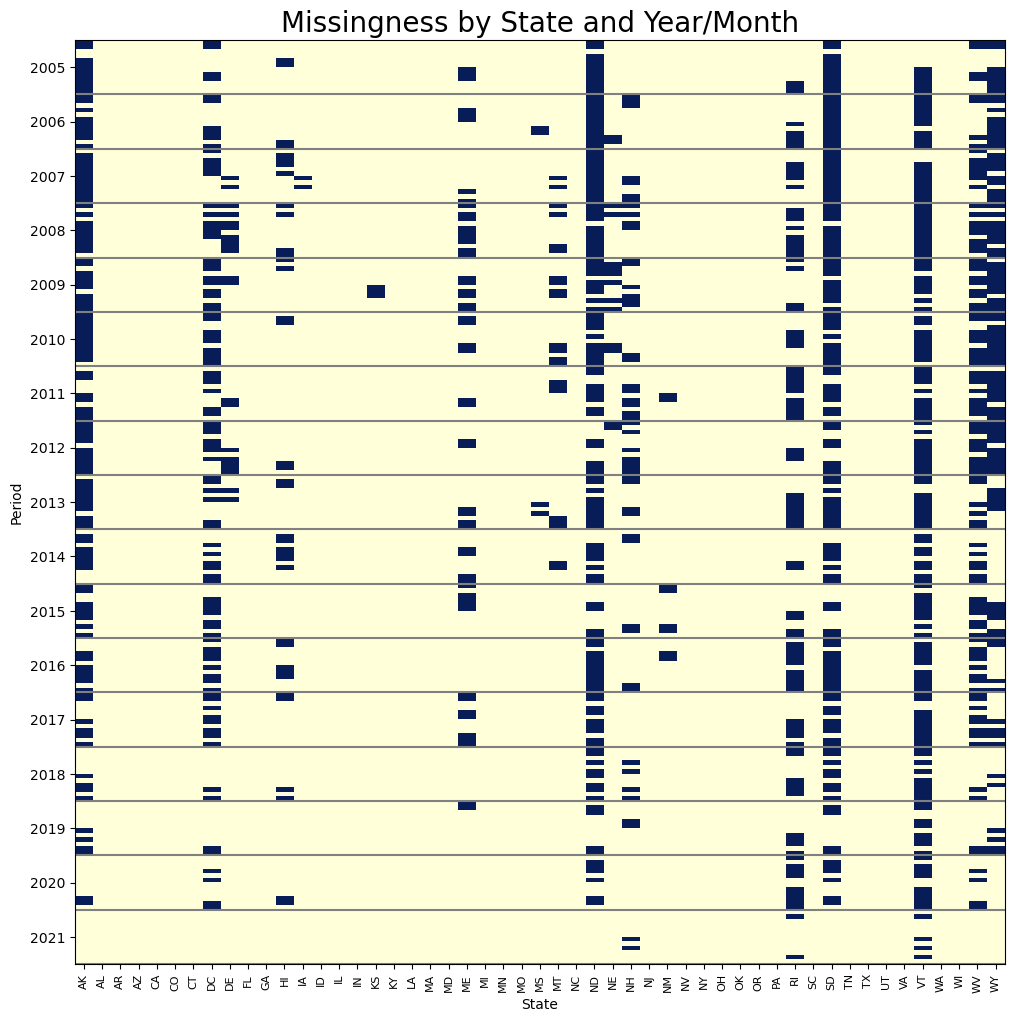

In [ ]:
# CREATING BOOLEAN FOR MISSINGNESS COLUMN
new_df['missing'] = new_df['state_formations'].isna()
print(new_df.head())


# PIVOTING DATA TO MATRIX (Reshaping panel to wide with missingness as the sole variable)
missing_matrix = new_df.pivot(index='per_idx', columns='STATE', values='missing')


# MAKING SUPPORT DATA OBJECTS TO USE IN FIGURE
# Period-year reference dataframe
index_years = new_df[['per_idx', 'year']].drop_duplicates().sort_values('per_idx').reset_index(drop = True)

# Average of month-level index values for each year group to create year markers in the middle of each year
year_positions = index_years.groupby('year').apply(lambda x : x.index.to_numpy().mean())

# Year boundary cutoffs within per_idx index for cutoff line positions
year_boundaries = index_years.groupby('year').apply(lambda x : x.index.max())


# CREATING THE ACTUAL GRAPH! 
plt.figure(figsize=(12,12))
plt.imshow(missing_matrix, aspect='auto', cmap = 'YlGnBu')

# Labeling x-axis with state abbreviations
plt.xticks(ticks = range(len(missing_matrix.columns)), 
        labels = missing_matrix.columns,
        rotation = 90, 
        fontsize = 8)

# Labeling y-axis with year markers
plt.yticks(
    ticks = year_positions.values,
    labels=year_positions.index
           )

# Adding cutoff line under each year
for boundary in year_boundaries.values:
        plt.axhline(boundary + 0.5, color='grey')


# Basic label details
plt.xlabel('State')
plt.ylabel('Period')
plt.title('Missingness by State and Year/Month', fontsize = 20)

plt.show()